<a href="https://colab.research.google.com/github/gilIolgenblum/CrowdingModeWorkshop/blob/main/tutorials/solutions/E2_fitting_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 2 — Solution: Fitting to Experimental Data

> ⚠️ **This is the solution notebook.** Students should attempt the exercises independently first.

In [6]:
import os
import sys

# Check if we are running in Google Colab
if 'google.colab' in str(get_ipython()):
    # Clone the repository to get the data files
    !git clone https://github.com/gilIolgenblum/CrowdingModeWorkshop.git
    # Change the working directory to the repository root
    os.chdir('/content/CrowdingModeWorkshop')
    # Install the package dependencies
    !pip install -e .

    # TELL PYTHON WHERE THE SOURCE FOLDER IS
    sys.path.append('/content/CrowdingModeWorkshop/src')

In [7]:
import crowding as cr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

---
## Task B1 — Load and Inspect the Data

**Steps:**
1. Load `aq16_sucrose_binary_format1.csv` using `pd.read_csv()`.
2. Print the first 5 rows and the number of data points.
3. Plot **$\Delta\Delta G^0$ vs concentration** (molal) as scatter points.

Number of data points: 5
   concentration       dG        dH       TdS
0        0.35503 -0.07822 -0.201105 -0.098386
1        0.64347 -0.24018 -0.743476 -0.549047
2        0.88245 -0.37435 -1.199538 -0.918320
3        1.08369 -0.46803 -1.503498 -1.114303
4        1.25547 -0.59688 -1.530653 -1.056619


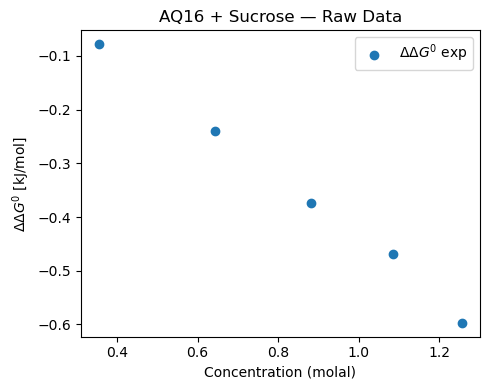

In [8]:
import os
DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), "../../fh_crowding_workshop", "app", "sample_data", "aq16_sucrose_binary_format1.csv")
# On Colab: DATA_PATH = "https://raw.githubusercontent.com/gilIolgenblum/CrowdingModeWorkshop/main/app/sample_data/aq16_sucrose_binary_format1.csv"

df = pd.read_csv(DATA_PATH)
print(f"Number of data points: {len(df)}")
print(df.head())

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(df["concentration"], df["dG"], label=r"$\Delta\Delta G^0$ exp")
ax.set_xlabel("Concentration (molal)")
ax.set_ylabel(r"$\Delta\Delta G^0$ [kJ/mol]")
ax.legend()
ax.set_title("AQ16 + Sucrose — Raw Data")
plt.tight_layout()
plt.show()

---
## Task B2 — Fit eps to $\Delta\Delta G^0$

**Steps:**
1. Create a `cr.Protein` (SASA=242.6) and a `cr.Cosolute` with the Sucrose parameters.
2. Construct a `cr.CrowdingModel` — start with `eps=0.0`, and `epsTS=0.0`.
3. Fit `eps` to the experimental $\Delta\Delta G^0$ data using `model.fit_eps()`.
4. Print the fitted `eps` value.

*Hint: Check tutorial 02 to see the calling convention for `fit_eps()`.*

In [9]:
AQ16 = cr.Protein(SASA=242.6)
sucrose = cr.Cosolute(nu=11.9, chi=0.452, chiTS=-0.854)

model = cr.CrowdingModel(
    protein=AQ16, cosolute=sucrose,
    eps=0.0, epsTS=0.0,
    phiC_max=0.25, dphiC=0.001
)

exp_conc = df["concentration"].values
exp_ddG  = df["dG"].values

model.fit_eps(exp_conc, exp_ddG, concentration_type="molal")
print(f"Fitted eps = {model.eps:.4f}")

Optimization terminated successfully.
         Current function value: 0.002809
         Iterations: 5
         Function evaluations: 16
         Gradient evaluations: 8
Fitted eps = -0.0697


---
## Task B3 — Fit epsTS and Plot

**Steps:**
1. After fitting `eps`, also fit `epsTS` from the experimental $\Delta\Delta H^0$ data using `model.fit_epsTS()`.
2. Use `cr.Plotter` to plot the model prediction overlaid on the experimental data for all three quantities:  
   **$\Delta\Delta G^0$**, **$\Delta\Delta H^0$**, **$T\Delta\Delta S^0$**.

*Hint: `cr.Plotter.plot_ddG()`, `plot_ddH()`, `plot_TddS()` each accept experimental data as arguments.*

Optimization terminated successfully.
         Current function value: 0.377407
         Iterations: 1
         Function evaluations: 6
         Gradient evaluations: 3
Fitted epsTS = 0.2160 kJ/mol


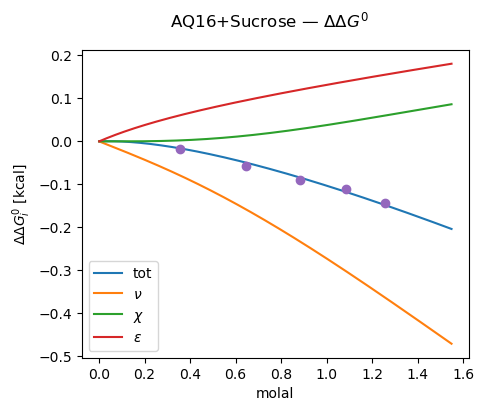

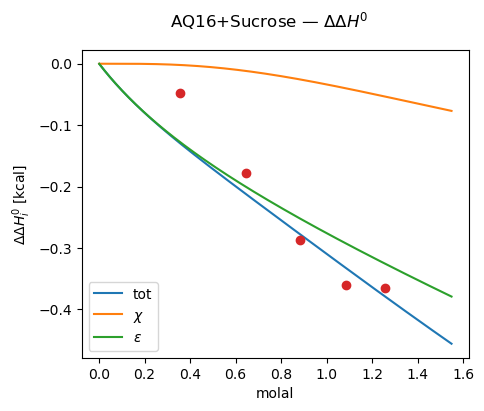

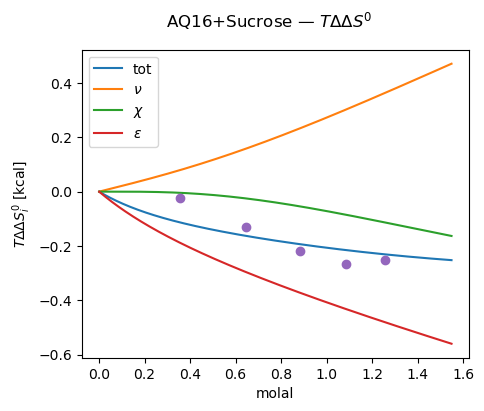

In [10]:
exp_ddH  = df["dH"].values
exp_TddS = df["TdS"].values

model.fit_epsTS(exp_conc, exp_ddH, exp_TddS, concentration_type="molal")
print(f"Fitted epsTS = {model.epsTS:.4f} kJ/mol")

plotter = cr.Plotter(model)

fig1 = plotter.plot_ddG(concentration_type="molal", folding=False,
                        exp_conc=exp_conc, exp_ddG=exp_ddG)
fig1.suptitle(r"AQ16+Sucrose — $\Delta\Delta G^0$")
plt.show()

fig2 = plotter.plot_ddH(concentration_type="molal", folding=False,
                        exp_conc=exp_conc, exp_ddH=exp_ddH)
fig2.suptitle(r"AQ16+Sucrose — $\Delta\Delta H^0$")
plt.show()

fig3 = plotter.plot_TddS(concentration_type="molal", folding=False,
                         exp_conc=exp_conc, exp_TddS=exp_TddS)
fig3.suptitle(r"AQ16+Sucrose — $T\Delta\Delta S^0$")
plt.show()

---
## Task B4 — Evaluate Fit Quality (RMSE)

The model produces a **continuous curve** over a fine $\phi$ grid. Your experimental data sits at discrete concentration points.

**Steps:**
1. Convert the experimental **molal** concentrations to volume fraction $\phi$ using `model.molal` and `model.phiC` arrays (use `np.interp` to invert the mapping).
2. Interpolate the model's **$\Delta\Delta G^0$ curve** at the experimental $\phi$ values.
3. Compute the **Root Mean Squared Error (RMSE)** between the interpolated model and the experimental $\Delta\Delta G^0$.
4. Print the RMSE value.

**Question (answer below):** Is the RMSE acceptable for biophysical data? What would you do if it were too large?

In [17]:
np.interp?

Signature:       np.interp(x, xp, fp, left=None, right=None, period=None)
Call signature:  np.interp(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function interp at 0x78d65c6e9da0>
File:            ~/miniforge3/envs/gilo2/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py
Docstring:      
One-dimensional linear interpolation for monotonically increasing sample points.

Returns the one-dimensional piecewise linear interpolant to a function
with given discrete data points (`xp`, `fp`), evaluated at `x`.

Parameters
----------
x : array_like
    The x-coordinates at which to evaluate the interpolated values.

xp : 1-D sequence of floats
    The x-coordinates of the data points, must be increasing if argument
    `period` is not specified. Otherwise, `xp` is internally sorted after
    normalizing the periodic boundaries with ``xp = xp % period``.

fp : 1-D sequence of float or complex
    The y-coordinates of the data points, same length as `xp`.

In [ ]:
# Convert experimental molal concentrations -> volume fraction
exp_phi = np.interp(exp_conc, model.molal, model.phiC)

# Interpolate model ΔΔG⁰ at experimental phi values
model_ddG_at_exp = np.interp(exp_phi, model.phiC, model.ddA_kj)

# RMSE
rmse = np.sqrt(np.mean((model_ddG_at_exp - exp_ddG)**2))
print(f"RMSE(ΔΔG⁰) = {rmse:.4f} kJ/mol")

RMSE(ΔΔG⁰) = 0.0237 kJ/mol


---
## Task B5 — Uncertainty via Monte Carlo Subsampling

**Steps:**
1. Define a function that fits `eps` on a subset of the experimental data.
2. Pass this function to `cr.monte_carlo_subsampling()` — run **50 iterations**, retaining **50%** of data points.
3. Report the **mean** and **standard deviation** of the distribution of fitted `eps` values.
4. Plot histogram of the values of `eps`

Monte Carlo Subsampling:   0%|          | 0/50 [00:00<?, ?it/s]

eps = -0.0697 ± 0.0023 kJ/mol (mean ± std, n=50)


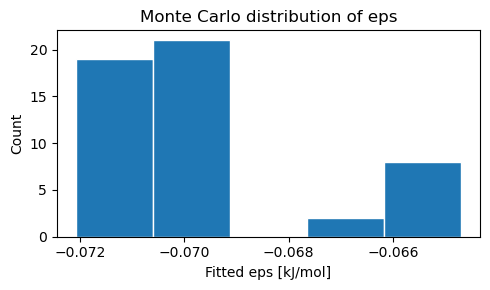

In [12]:
def fit_and_extract_eps(idx):
    # 1. Slice the experimental arrays using the randomized indices
    sub_conc = exp_conc[idx]
    sub_ddG = exp_ddG[idx]
    
    # 2. Run the fit silently
    model.fit_eps(sub_conc, sub_ddG, concentration_type='molal', disp=False, progress_bar=False, auto_solve=False)
    return {'eps': model.eps}
 
# This will take a few seconds
results = cr.monte_carlo_subsampling(
    n_points=len(exp_conc),
    fit_and_extract=fit_and_extract_eps,
    n_iterations=50,
    subsample_fraction=0.5,
    progress_bar=True
)

eps_values = results["eps"].values
print(f"eps = {eps_values.mean():.4f} ± {eps_values.std():.4f} kJ/mol (mean ± std, n=50)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(eps_values, bins=5, edgecolor="white")
ax.set_xlabel("Fitted eps [kJ/mol]")
ax.set_ylabel("Count")
ax.set_title("Monte Carlo distribution of eps")
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.tight_layout()
plt.show()


---
## Task B6 — Impact of the Number of Iterations on Uncertainty

**Steps:**
1. Repeat the analysis from Task B5 using several different numbers of iterations.
2. Plot the estimated uncertainty as a function of the number of iterations.
3. Examine how the uncertainty changes as the number of iterations increases.

**Question:**  
How many iterations are required for the estimated uncertainty to converge?

In [13]:
iterators = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 35, 50, 75, 100, 200, 300, 400, 500]#, 1000, 2000]

unc = []
for iterator in iterators:
    results = cr.monte_carlo_subsampling(
    n_points=len(exp_conc),
    fit_and_extract=fit_and_extract_eps,
    n_iterations=iterator,
    subsample_fraction=0.5,
    progress_bar=True
    )
    unc.append(results["eps"].values.std())


Monte Carlo Subsampling:   0%|          | 0/1 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/2 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/3 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/4 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/5 [00:00<?, ?it/s]

...

Monte Carlo Subsampling:   0%|          | 0/100 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/200 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/300 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/400 [00:00<?, ?it/s]

Monte Carlo Subsampling:   0%|          | 0/500 [00:00<?, ?it/s]

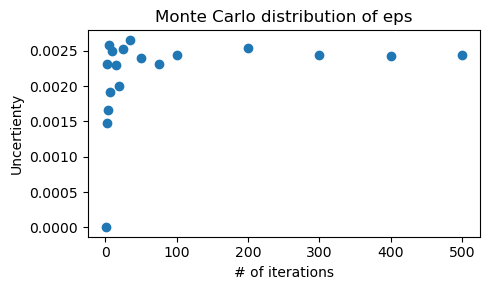

In [14]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(iterators, unc, 'o')
ax.set_xlabel("# of iterations")
ax.set_ylabel("Uncertienty")
ax.set_title("Monte Carlo distribution of eps")
plt.tight_layout()
plt.show()

For #iteractions>50 the uncertienty seems converged.

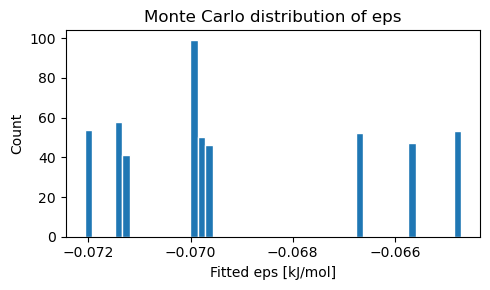

In [15]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(results["eps"].values, bins=50, edgecolor="white")
ax.set_xlabel("Fitted eps [kJ/mol]")
ax.set_ylabel("Count")
ax.set_title("Monte Carlo distribution of eps")
from matplotlib.ticker import MaxNLocator
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
plt.tight_layout()
plt.show()